### Call packages, define constants and variables

In [1]:
include("essential_code.jl"); #call the script that contains most of the functions
using ExponentialUtilities
using JLD2
using DSP

In [2]:
const dt = 0.005;
const n_seg = 50; #number of segments
const τmin = dt; #minimum duration of a single segment
const τmax = 100*dt; #total max time of τmax*n_seg = 40  (for now)
const t_wait = 2.0; 

#define constants from the Hamiltonian
const Δ_2 = 0; #detunings 
const Δ_1 = 0;
const Δ_c = 0;
const Ω_amplitude = 15; #amplitudes for the control signals. This means it is NOT the max value. The max value is this divided by two. 
const ϵ_amplitude = 15;
const g = 1; #coupling between matter and light
κ = [5, 5] #coupling between the cavity and the waveguides
C = [0 1; 1 0] #Matrix that appears from the SLH
#τvector = 0.5*ones(n_seg)
#Collapse operators for Lindblad master equation
γ = [.2, .2]; #for both cavities, this term defines the rate 
collapse_ops = [sqrt(γ[1])*c_ops[1], sqrt(γ[2])*c_ops[2]]; #vector of the collapse operators, it is the anhilitation operators for each of the two cavities.

#const  pulse = tukey_window(n_seg);
const pulse = tukey(n_seg, 0.3);
tF = 5.0
#τvector = 0.5*ones(n_seg);
tlist = 0:dt:tF
#const cumsum_τvector = cumsum(τvector)



#

function get_τvector_noceil(τ, τmin::Real, τmax::Real, dt::Real)
    σ(x) = τmin + (τmax - τmin)/(1 + exp(-x)) 
    #return ceil.(σ.(τ.- 1)./dt).*dt #I use ceil and multiply and divide by dt because I want a duration that actually belongs to my time grid  
    return σ.(τ)
end


get_τvector_noceil (generic function with 1 method)

In [3]:
#initialization of Hamiltonian and Liouvillian terms, as well as of quantum states
H_terms = create_H_terms(κ, C)

H0 = H_terms.H0
H_Ω = H_terms.H_Ω
H_ϵ = H_terms.H_ϵ

H0_QO = H_terms.H0_QO
H_Ω_QO = H_terms.H_Ω_QO
H_ϵ_QO = H_terms.H_ϵ_QO


L_terms = create_terms_L([collapse_ops[1].data, collapse_ops[2].data]);

L_H0 = L_terms.L_H0
L_HΩ = L_terms.L_HΩ
L_Hϵ = L_terms.L_Hϵ
L_diss = L_terms.L_diss

#creation of initial state
ψ0 = tensor(basis(N_fock, 0), g_1, basis(N_fock, 0), g_1); #[|0) ⊗ |g_1)] ⊗ [|0) ⊗ |g_1)]
ψ0_QO = ψ0
ψ0 = ψ0.data; #we just want the vector representation
#desired state (notice that it is just defined in the matter system)
ψT_matter = (tensor(g_1, g_1) + tensor(g_2, g_2))/sqrt(2);
ψT_matter = ψT_matter.data;


### Definition of different cost functions

In [ ]:
function cost_this(u, params) #this cost function just considers the fidelity and considers a constant max time. 
    (; Ω_amplitude, ϵ_amplitude, ψ0, t_wait, ψT_matter, κ, H0, H_Ω, H_ϵ, tF) = params
  
    #define the indexes for the functions
    idx_Ω = 1:2*n_seg*N_rails;
    idx_ϵ = 2*n_seg*N_rails+1 : 4*n_seg*N_rails;

    #define the things that will actually go into the Hamiltonian (these depend on the parameter p)
    ΩMatrix = create_ΩMatrix(view(u, idx_Ω), Ω_amplitude, pulse);
    ϵMatrix = create_ϵMatrix(view(u, idx_ϵ), ϵ_amplitude, pulse);
    τvector = tF/n_seg*ones(n_seg)

    ψf = Hamiltonian_evolution(ψ0, H0, H_Ω, H_ϵ, ΩMatrix, ϵMatrix, τvector; t_wait = t_wait)

    ρm = partial_trace_cavities(ψf)
    Fsum = real(ψT_matter'*ρm*ψT_matter)

    return (1-Fsum)
end

cost_this (generic function with 1 method)

In [ ]:
#This cost functions considers in addition to the fidelity the duration of the signal and the bandwitdh
function cost_work(u, params)

    (; Ω_amplitude, ϵ_amplitude, ψ0, t_wait, ψT_matter, κ, H0, H_Ω, H_ϵ) = params
  
    #this values are weights for each term of the cost function 
    a = 1
    b = 0
    #c = 0.005
    c = 0.001
    d = 1
    #define the indexes for the functions
    idx_Ω = 1:2*n_seg*N_rails;
    idx_ϵ = 2*n_seg*N_rails+1 : 4*n_seg*N_rails;
    idx_τ = 4*n_seg*N_rails+1 : length(u);

    #define the things that will actually go into the Hamiltonian (these depend on the parameter p)
    ΩMatrix = create_ΩMatrix(view(u, idx_Ω), Ω_amplitude, pulse);
    ϵMatrix = create_ϵMatrix(view(u, idx_ϵ), ϵ_amplitude, pulse);
    τvector = create_τvector(d .* view(u, idx_τ), τmin, τmax, dt)
    τvector_noceil = get_τvector_noceil(d .* view(u, idx_τ), τmin, τmax, dt)


    ψf = Hamiltonian_evolution(ψ0, H0, H_Ω, H_ϵ, ΩMatrix, ϵMatrix, τvector; t_wait = t_wait)

    ρm = partial_trace_cavities(ψf)
    Fsum = real(ψT_matter'*ρm*ψT_matter)

    T = sum(τvector_noceil)
    
    
    Δτvector = (τvector[1:end-1] .+ τvector[2:end])/2

    function getD(CF) #this computes a quantity proportional to the module square of the derivative of the control field, which is related with the bandwitdh of the signals.
        sum(abs2.(diff(CF)./Δτvector).* Δτvector)/(sum(abs2.(CF)) + 1e-11)
    end

    D = 1/8*( getD(real.(ΩMatrix[:, 1])) +  getD(real.(ΩMatrix[:, 2])) +  getD(imag.(ΩMatrix[:, 1])) +  getD(imag.(ΩMatrix[:, 2])) + getD(real.(ϵMatrix[:, 1])) +  getD(real.(ϵMatrix[:, 2])) +  getD(imag.(ϵMatrix[:, 1])) +  getD(imag.(ϵMatrix[:, 2])) )

    return a*(1-Fsum) + b*T + c*D
end


cost_work (generic function with 1 method)

In [ ]:
#This cost function considers just the fidelity. It is different from the first one because the time could potentially be modified because it is a tunable parameter.
function cost_work_onlyF(u, params)
    (; Ω_amplitude, ϵ_amplitude, ψ0, t_wait, ψT_matter, κ, H0, H_Ω, H_ϵ, tF) = params
    idx_Ω = 1:2*n_seg*N_rails;
    idx_ϵ = 2*n_seg*N_rails+1 : 4*n_seg*N_rails;
    idx_τ = 4*n_seg*N_rails+1 : length(u);

    ΩMatrix = create_ΩMatrix(view(u, idx_Ω), Ω_amplitude, pulse);
    ϵMatrix = create_ϵMatrix(view(u, idx_ϵ), ϵ_amplitude, pulse);
        
    τvector = create_τvector(view(u, idx_τ), τmin, τmax, dt)

    ψf = Hamiltonian_evolution(ψ0, H0, H_Ω, H_ϵ, ΩMatrix, ϵMatrix, τvector; t_wait = t_wait)

    ρm = partial_trace_cavities(ψf)
    Fsum = real(ψT_matter'*ρm*ψT_matter)


    return 1-Fsum
end

cost_work_onlyF (generic function with 1 method)

In [7]:
function cost_values(u)
    
    a = 1
    b = 0.0#08
    c = 0.001
    c = 0
    d = 1

    idx_Ω = 1:2*n_seg*N_rails;
    idx_ϵ = 2*n_seg*N_rails+1 : 4*n_seg*N_rails;
    idx_τ = 4*n_seg*N_rails+1 : length(u);
    #define the things that will actually go into the Hamiltonian (these depend on the parameter p)
    
    ΩMatrix = create_ΩMatrix(view(u, idx_Ω), Ω_amplitude, pulse);
    ϵMatrix = create_ϵMatrix(view(u, idx_ϵ), ϵ_amplitude, pulse);
    τvector = create_τvector(d .* view(u, idx_τ), τmin, τmax, dt)
    τvector_noceil = get_τvector_noceil(d .* view(u, idx_τ), τmin, τmax, dt)
    
    ψf = Hamiltonian_evolution(ψ0, H0, H_Ω, H_ϵ, ΩMatrix, ϵMatrix, τvector; t_wait = t_wait)

    ρm = partial_trace_cavities(ψf)
    Fsum = real(ψT_matter'*ρm*ψT_matter)

    T = sum(τvector_noceil)
    

    Δτvector = (τvector[1:end-1] .+ τvector[2:end])/2

    function getD(CF)
        sum(abs2.(diff(CF)./Δτvector).* Δτvector)/(sum(abs2.(CF)) + 1e-11)
    end

    D = 1/8*( getD(real.(ΩMatrix[:, 1])) +  getD(real.(ΩMatrix[:, 2])) +  getD(imag.(ΩMatrix[:, 1])) +  getD(imag.(ΩMatrix[:, 2])) + getD(real.(ϵMatrix[:, 1])) +  getD(real.(ϵMatrix[:, 2])) +  getD(imag.(ϵMatrix[:, 1])) +  getD(imag.(ϵMatrix[:, 2])) )


    return(F = Fsum, T = T, b = b, D = D, c = c)
end

cost_values (generic function with 1 method)

In [ ]:
u0 = vcat(ones(4*n_seg*N_rails), τ_value*ones(n_seg));

params = (
    Ω_amplitude = Ω_amplitude, 
    ϵ_amplitude = ϵ_amplitude,  
    ψ0 = ψ0, 
    t_wait = t_wait, 
    ψT_matter = ψT_matter,
    κ = κ,
    H0 = H0,
    H_Ω = H_Ω,
    H_ϵ =  H_ϵ,
    collapse_ops = collapse_ops,
    L_H0 = L_H0,
    L_HΩ = L_HΩ,
    L_Hϵ = L_Hϵ,
    L_diss = L_diss,
    tF = tF
    #τvector = τvector
);


In [9]:
function plot_fields(u)
    ΩMatrix_solution = create_ΩMatrix(u[1:2*n_seg*N_rails], Ω_amplitude, pulse);
    ϵMatrix_solution = create_ϵMatrix(u[2*n_seg*N_rails+1: 4*n_seg*N_rails], ϵ_amplitude, pulse);
    τvector_solution = create_τvector(u[4*n_seg*N_rails+1:end], τmin, τmax, dt)
    tlist_solution = 0:dt:ceil(sum(τvector_solution)/dt + t_wait/dt)*dt 

    tlist_solution_fields = 0:dt:ceil(sum(τvector_solution)/dt)*dt  #No time wait
    ΩMatrix_solution_tlist = n_seg2t_list(ΩMatrix_solution, τvector_solution, tlist_solution);
    ϵMatrix_solution_tlist = n_seg2t_list(ϵMatrix_solution, τvector_solution, tlist_solution);

      f2 = Figure(size = (900, 800))

    ax5 = make_plot!(f2[1, 1], real.(ϵMatrix_solution_tlist)', tlist_solution, L"\text{Re} (\mathcal{E}) \   \ \text{(optimized parameters)}", L"\text{Scaled } \; \; ")
    ax6 = make_plot!(f2[1, 2], imag.(ϵMatrix_solution_tlist)', tlist_solution, L"\text{Im}(\mathcal{E}) \   \ \text{(optimized parameters)}", L"\text{Scaled } \; \; ")
    ax7 = make_plot!(f2[2, 1], real.(ΩMatrix_solution_tlist)', tlist_solution, L"\text{Re}(\Omega) \   \ \text{(optimized parameters)}", L"\text{Scaled } \; \; ")
    ax8 = make_plot!(f2[2, 2], imag.(ΩMatrix_solution_tlist)', tlist_solution, L"\text{Im}(\Omega) \   \ \text{(optimized parameters)}", L"\text{Scaled } \; \; ")

    return f2
end

plot_fields (generic function with 1 method)

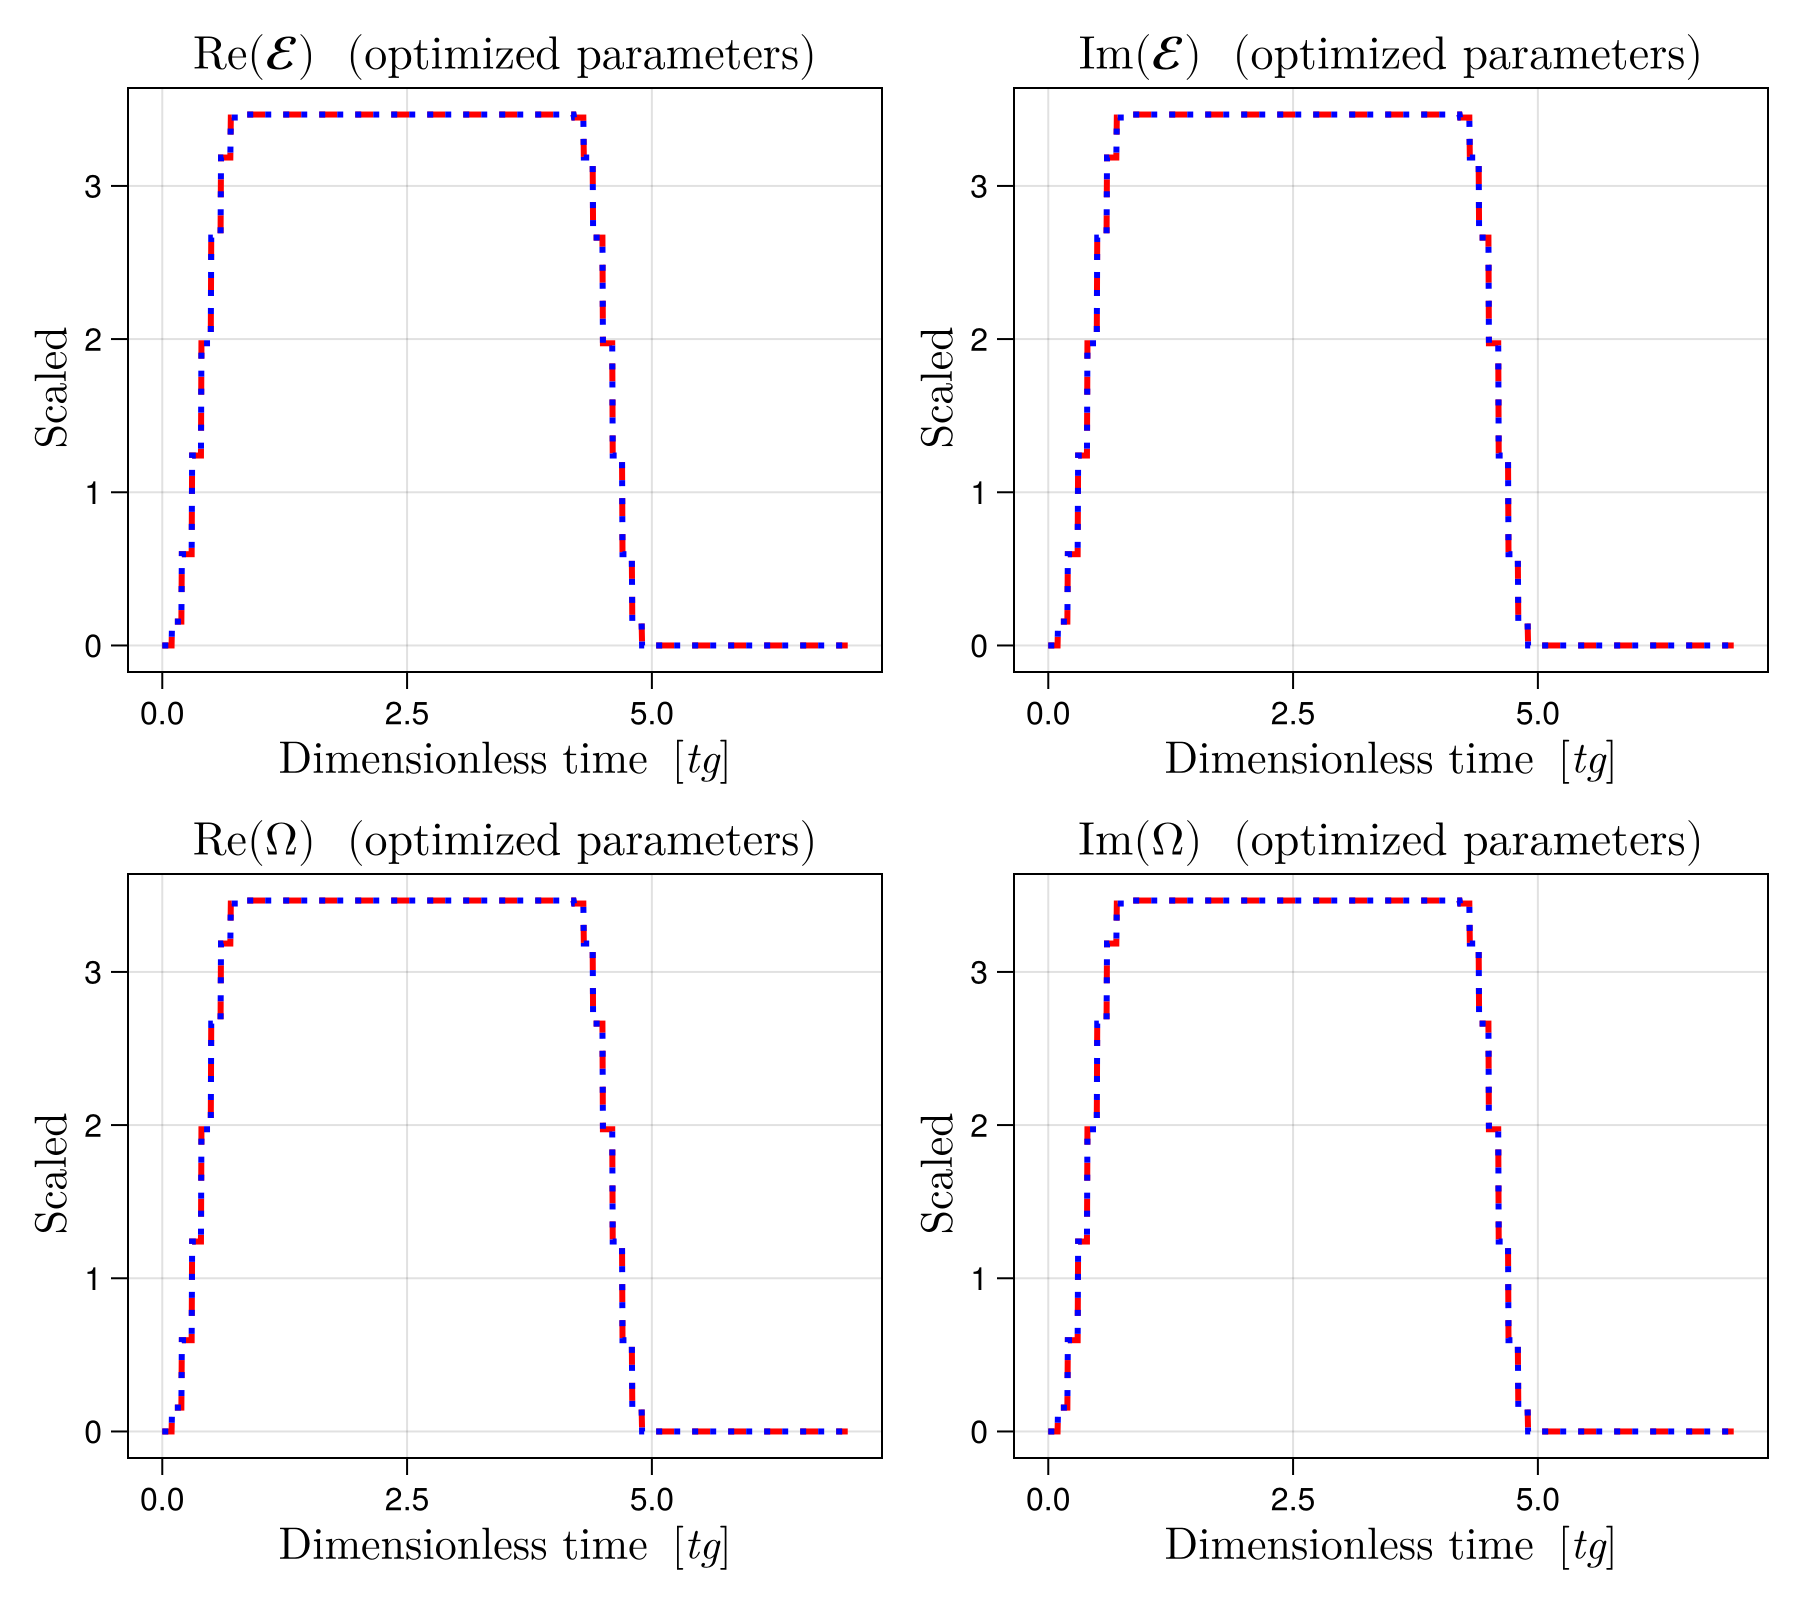

In [10]:
plot_fields(u0)

In [11]:
cost_values(u0)

(F = 0.17916598882391316, T = 5.000000000000001, b = 0.0, D = 0.08311824741718354, c = 0)

In [12]:
sol_original = solve_problem(cost_work_onlyF, u0, params, lbfgs_iters=100);

Starting Adam phase...
Iteration: 10 | Cost: 0.480649
Iteration: 20 | Cost: 0.358425
Iteration: 30 | Cost: 0.330681
Iteration: 40 | Cost: 0.30382
Iteration: 50 | Cost: 0.286655
Iteration: 60 | Cost: 0.273342
Iteration: 70 | Cost: 0.261691
Iteration: 80 | Cost: 0.250469
Iteration: 90 | Cost: 0.239518
Iteration: 100 | Cost: 0.228751
Iteration: 100 | Cost: 0.228751
Adam finished with cost: 0.22875069199726572
Starting L-BFGS phase...
Iteration: 0 | Cost: 0.228751
Iteration: 10 | Cost: 0.153976
Iteration: 20 | Cost: 0.120147
Iteration: 30 | Cost: 0.093438
Iteration: 40 | Cost: 0.07872
Iteration: 50 | Cost: 0.067064
Iteration: 60 | Cost: 0.060663
Iteration: 70 | Cost: 0.056455
Iteration: 80 | Cost: 0.05166
Iteration: 90 | Cost: 0.048571
Iteration: 100 | Cost: 0.045015
L-BFGS finished with final cost: 0.04501508414020838


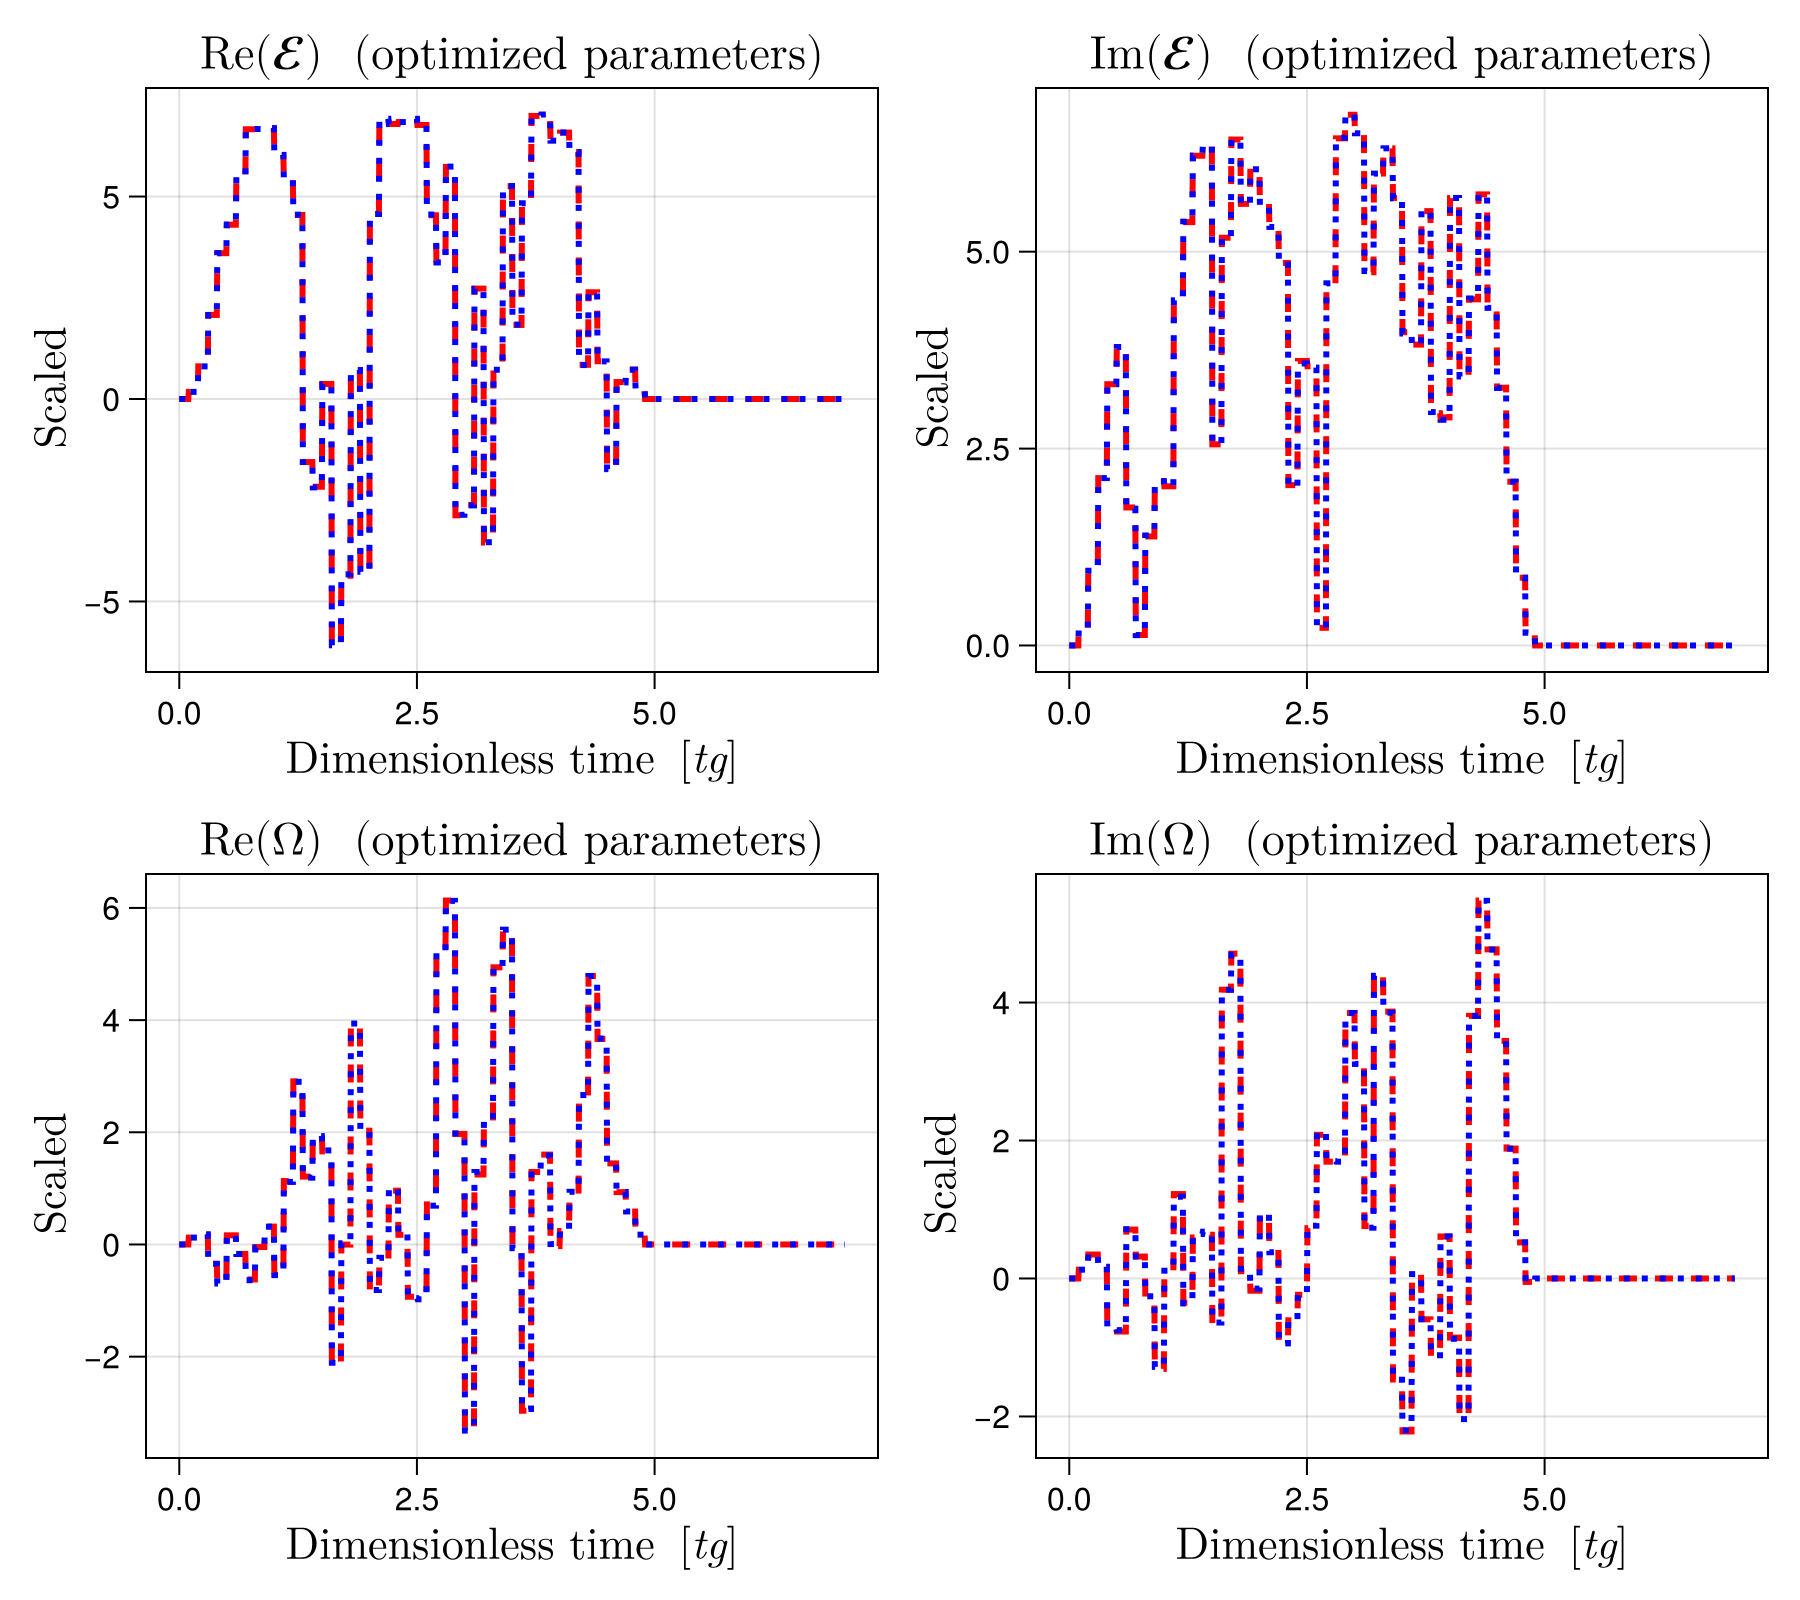

In [13]:
plot_fields(sol_original.u)

In [14]:
u_random = vcat(0.5*(rand(4*n_seg*N_rails) .- 0.5), τ_value*ones(n_seg));
sol = solve_problem(cost_work, u_random, params, lbfgs_iters=1000);



Starting Adam phase...
Iteration: 10 | Cost: 0.557676
Iteration: 20 | Cost: 0.526987
Iteration: 30 | Cost: 0.503897
Iteration: 40 | Cost: 0.482489
Iteration: 50 | Cost: 0.459361
Iteration: 60 | Cost: 0.422644
Iteration: 70 | Cost: 0.327724
Iteration: 80 | Cost: 0.229702
Iteration: 90 | Cost: 0.167261
Iteration: 100 | Cost: 0.13278
Iteration: 100 | Cost: 0.13278
Adam finished with cost: 0.1327802234756546
Starting L-BFGS phase...
Iteration: 0 | Cost: 0.13278
Iteration: 10 | Cost: 0.099657
Iteration: 20 | Cost: 0.072615
Iteration: 30 | Cost: 0.051094
Iteration: 40 | Cost: 0.038577
Iteration: 50 | Cost: 0.032499
Iteration: 60 | Cost: 0.027883
Iteration: 70 | Cost: 0.025654
Iteration: 80 | Cost: 0.023776
Iteration: 90 | Cost: 0.022802
Iteration: 100 | Cost: 0.021983
Iteration: 110 | Cost: 0.021367
Iteration: 120 | Cost: 0.020836
Iteration: 130 | Cost: 0.020529
Iteration: 140 | Cost: 0.020243
Iteration: 150 | Cost: 0.020026
Iteration: 160 | Cost: 0.019853
Iteration: 170 | Cost: 0.019665
Ite

In [15]:
cost_values(sol.u)

(F = 0.9903407469679419, T = 5.000000000000001, b = 0.0, D = 4.5936171373283194, c = 0)

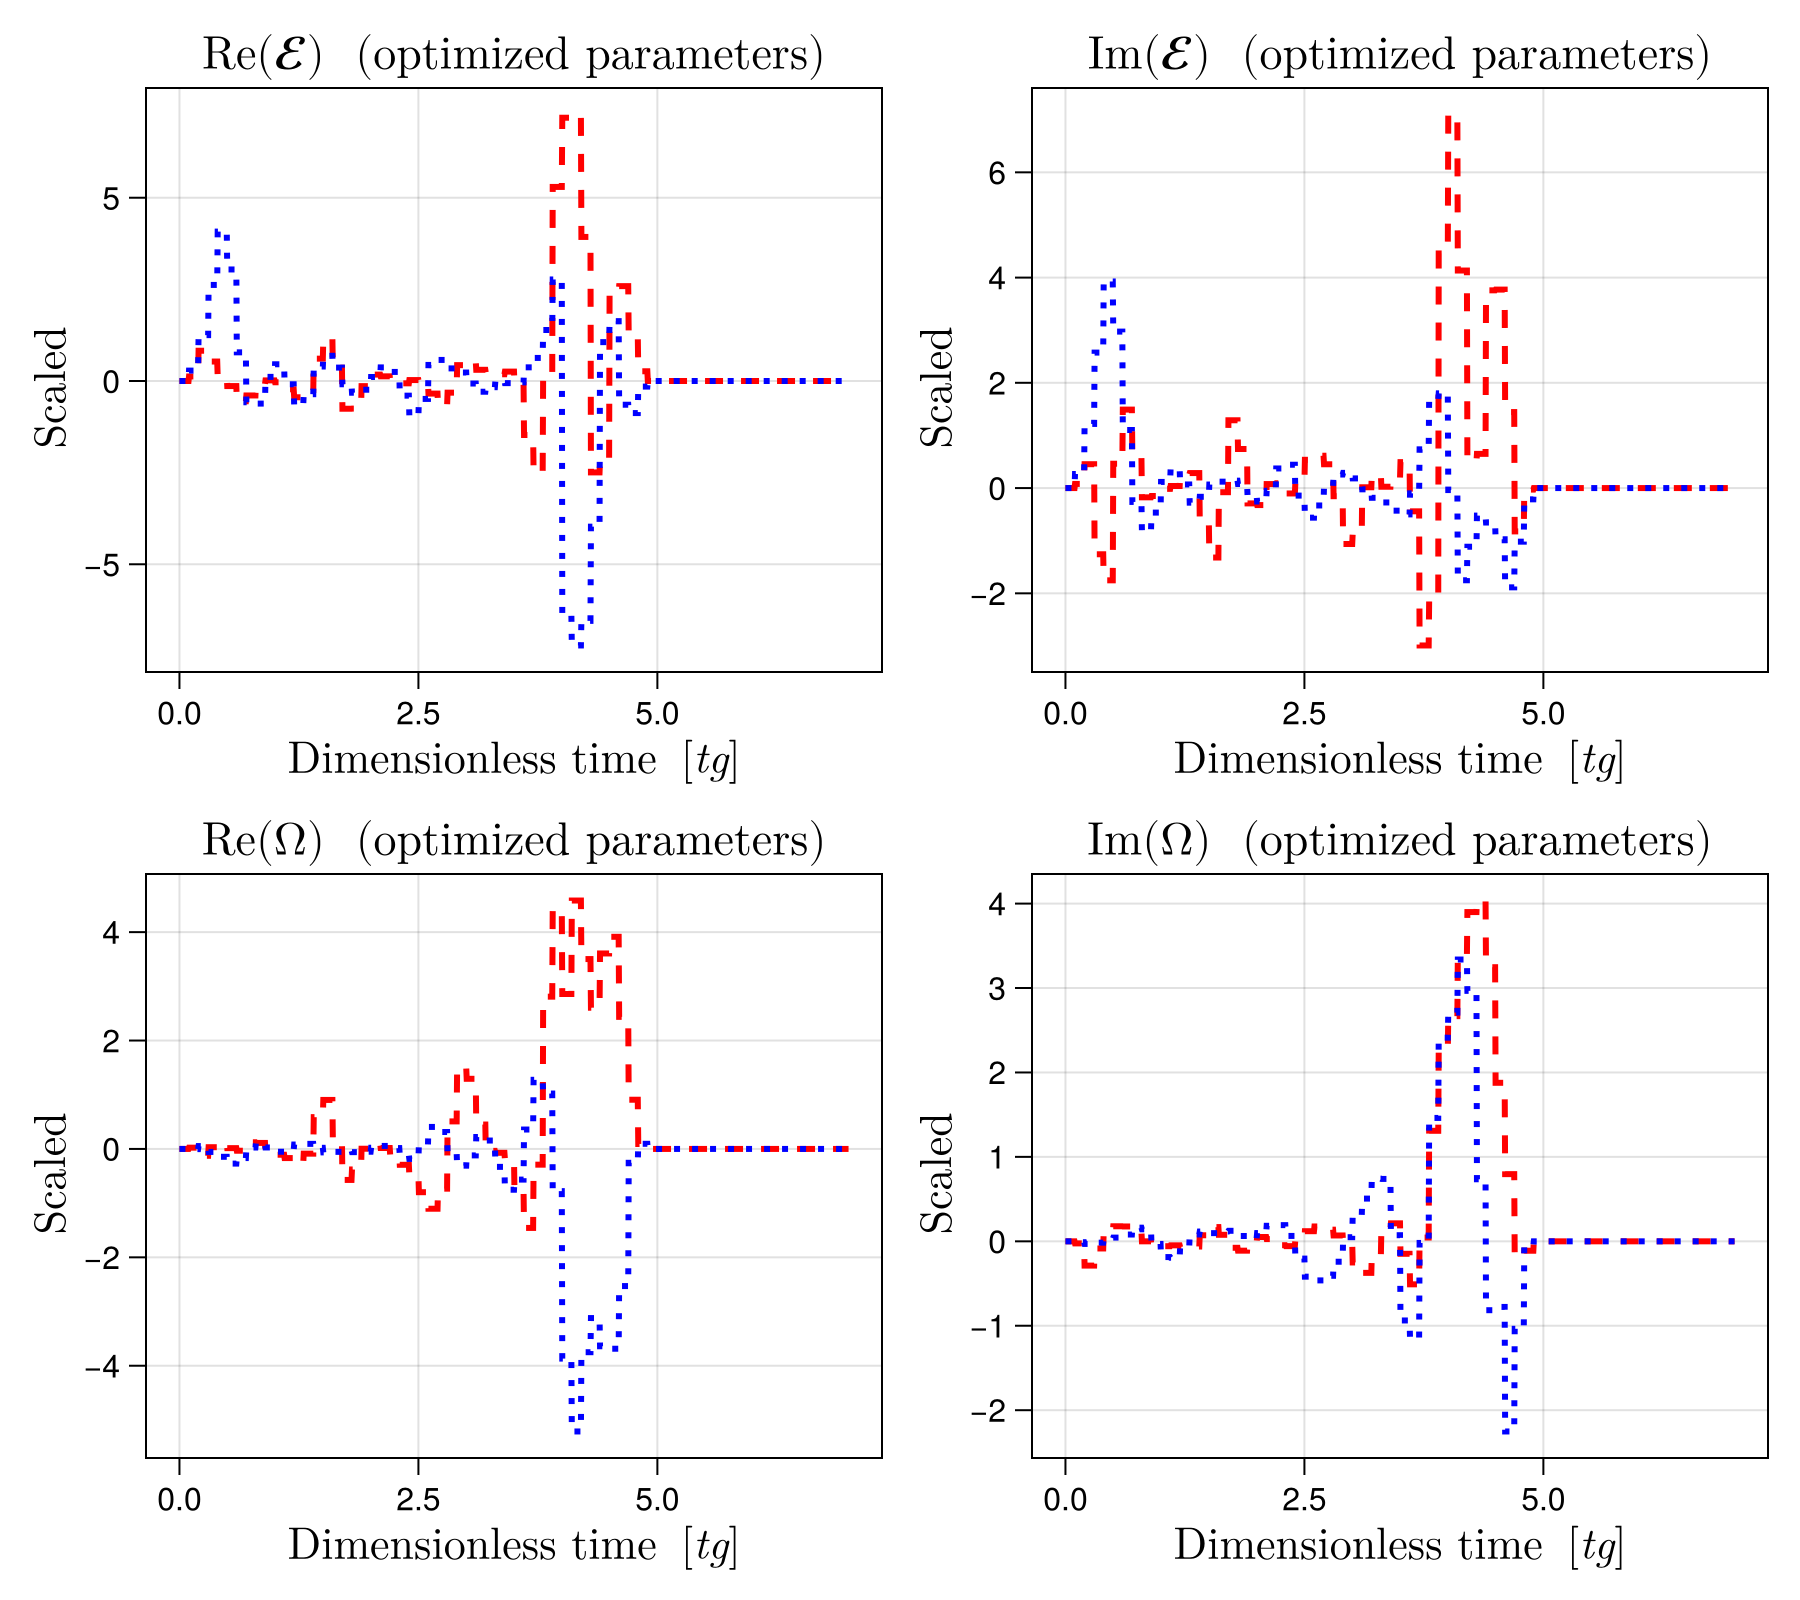

In [16]:
plot_fields(sol.u)

In [17]:
ΩMatrix_solution = create_ΩMatrix(sol.u[1:2*n_seg*N_rails], Ω_amplitude, pulse);
ϵMatrix_solution = create_ϵMatrix(sol.u[2*n_seg*N_rails+1: 4*n_seg*N_rails], ϵ_amplitude, pulse);
τvector =create_τvector(sol.u[4*n_seg*N_rails+1:end], τmin, τmax, dt)

50-element Vector{Float64}:
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 ⋮
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1